# Project 05: RNA-Seq Differential Expression & Pathway Analysis Walkthrough
### *Interactive Portfolio Walkthrough: DESeq2 Normalization, Wald Differential Expression, and Pathway Enrichment*

**Author:** Bioinformatics & Scientific Software Engineer  
**Dataset:** GSE153664 (Human muscle/androgen receptor target transcriptomics, 3 Control vs. 3 Treated)  
**Stack:** Python 3.11+, Pandas, NumPy, SciPy, Seaborn, Matplotlib  

---

In [1]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve()
while not (repo_root / "pyproject.toml").exists() and repo_root.parent != repo_root:
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
project_dir = repo_root / "projects" / "05-rna-seq"
if str(project_dir) not in sys.path:
    sys.path.insert(0, str(project_dir))


from src.differential_expression import run_differential_expression
from src.normalization import calculate_size_factors, normalize_counts
from src.pathway_enrichment import run_pathway_enrichment
from src.visualizer import plot_expression_heatmap, plot_pathway_enrichment, plot_pca, plot_volcano

from shared.io.tabular import load_dataframe
from shared.visualization.style import apply_scientific_style

apply_scientific_style()
print("Project 05 RNA-Seq modules initialized successfully.")

Project 05 RNA-Seq modules initialized successfully.


## 1. Load Raw Counts & Sample Metadata
We load the GSE153664 count matrix (547 genes across 6 biological replicates) and sample metadata.


In [2]:
counts_path = project_dir / "data" / "raw_counts_matrix.tsv"
metadata_path = project_dir / "data" / "sample_metadata.csv"

raw_counts = load_dataframe(counts_path, sep="	")
metadata = load_dataframe(metadata_path, sep=",")

ctrl_samples = metadata[metadata["condition"] == "Control"]["sample_id"].tolist()
treat_samples = metadata[metadata["condition"] == "Treated"]["sample_id"].tolist()
all_samples = ctrl_samples + treat_samples

print(f"Raw counts matrix shape: {raw_counts.shape}")
print(f"Control samples: {ctrl_samples}")
print(f"Treated samples: {treat_samples}")
metadata.head(6)

[09/07/26 00:27:36] INFO     Loaded DataFrame with shape (547, 7) from raw_counts_matrix.tsv

                    INFO     Loaded DataFrame with shape (6, 5) from sample_metadata.csv

Raw counts matrix shape: (547, 7)
Control samples: ['Control_Rep1', 'Control_Rep2', 'Control_Rep3']
Treated samples: ['Treated_Rep1', 'Treated_Rep2', 'Treated_Rep3']


,sample_id,condition,replicate,batch,total_reads
0,Control_Rep1,Control,1,Batch1,28450120
1,Control_Rep2,Control,2,Batch1,26980450
2,Control_Rep3,Control,3,Batch2,31200840
3,Treated_Rep1,Treated,1,Batch1,29540600
4,Treated_Rep2,Treated,2,Batch1,30120300
5,Treated_Rep3,Treated,3,Batch2,27890550


## 2. DESeq2 Median-of-Ratios Normalization
Calculate geometric pseudo-reference, per-sample gene-to-reference ratios, and median size factors.


In [3]:
size_factors = calculate_size_factors(raw_counts, all_samples)
for s, sf in size_factors.items():
    print(f"  {s:15s} -> Size Factor = {sf:.4f}")

norm_counts, log2_counts = normalize_counts(raw_counts, all_samples, size_factors)
norm_counts.head()

[09/07/26 00:27:36] INFO     Computed size factors: {'Control_Rep1': 1.0174, 'Control_Rep2': 0.9998,               
                             'Control_Rep3': 1.0055, 'Treated_Rep1': 1.0216, 'Treated_Rep2': 1.0178,               
                             'Treated_Rep3': 1.0231}

  Control_Rep1    -> Size Factor = 1.0174
  Control_Rep2    -> Size Factor = 0.9998
  Control_Rep3    -> Size Factor = 1.0055
  Treated_Rep1    -> Size Factor = 1.0216
  Treated_Rep2    -> Size Factor = 1.0178
  Treated_Rep3    -> Size Factor = 1.0231


,gene_id,Control_Rep1,Control_Rep2,Control_Rep3,Treated_Rep1,Treated_Rep2,Treated_Rep3
0,KLK3,5310.60,8246.65,6344.11,30182.07,32557.48,19628.58
1,FKBP5,1940.24,2144.43,2582.79,7599.84,14116.72,13288.05
2,TMPRSS2,41.28,59.01,35.80,216.33,309.49,372.40
3,NKX3-1,106.15,369.07,293.39,1437.94,1670.27,1484.70
4,SLC45A3,88.46,54.01,75.58,194.79,138.53,278.57


## 3. Differential Expression Analysis (Wald Test & BH FDR Control)
Contrast: Treated vs. Control. Compute log2 fold changes, Wald statistics, and Benjamini-Hochberg adjusted FDR.


In [4]:
de_results, de_summary = run_differential_expression(
    norm_counts,
    control_samples=ctrl_samples,
    treated_samples=treat_samples,
    fdr_cutoff=0.05,
    log2fc_cutoff=1.0,
    min_count_sum=10,
)

sig_genes_df = de_results[de_results["status"] != "Not Significant"].copy()
print(f"Total genes tested: {de_summary.total_genes_tested}")
print(f"Significantly Upregulated: {de_summary.num_significant_up}")
print(f"Significantly Downregulated: {de_summary.num_significant_down}")
sig_genes_df.head(10)

[09/07/26 00:27:36] INFO     Differential Expression: 547 genes tested. Significant Up: 18, Significant Down: 10,  
                             Non-significant: 519.

Total genes tested: 547
Significantly Upregulated: 18
Significantly Downregulated: 10


,gene_id,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,status
0,NKX3-1,893.59,2.577,0.175,14.72,4.841337e-49,2.648211e-46,Up-regulated
1,GUCY1A3,150.04,2.336,0.176,13.25,4.371482e-40,1.195600e-37,Up-regulated
2,MAOA,202.86,1.852,0.177,10.45,1.415614e-25,2.581137e-23,Up-regulated
3,ABCC4,1853.06,2.668,0.308,8.67,4.215367e-18,5.764514e-16,Up-regulated
4,ACSL3,240.84,2.235,0.262,8.52,1.604558e-17,1.755387e-15,Up-regulated
5,IGF1R,274.69,1.812,0.238,7.60,2.853141e-14,2.601113e-12,Up-regulated
6,NDRG1,319.24,1.540,0.216,7.14,9.035966e-13,7.060962e-11,Up-regulated
7,ZBTB10,150.84,2.436,0.353,6.90,5.223733e-12,3.571728e-10,Up-regulated
8,TMPRSS2,172.38,2.709,0.396,6.84,8.016173e-12,4.872052e-10,Up-regulated
9,SEC14L2,215.87,1.238,0.183,6.77,1.255230e-11,6.866108e-10,Up-regulated


## 4. Pathway Over-Representation Analysis (ORA)
Evaluate biological pathways enriched in significant genes using hypergeometric testing.


In [5]:
sig_set = set(sig_genes_df["gene_id"])
bg_set = set(de_results["gene_id"])
enrichment_df = run_pathway_enrichment(sig_set, bg_set, p_val_cutoff=0.05)
print(f"Enriched pathways (p < 0.05): {len(enrichment_df)}")
enrichment_df

[09/07/26 00:27:36] INFO     Pathway enrichment identified 6 significant terms at p < 0.05.

Enriched pathways (p < 0.05): 6


,term_id,pathway_name,category,overlap_count,pathway_size,fold_enrichment,p_value,neg_log10_p,overlapping_genes
0,KEGG:05215,Androgen Receptor Signaling Pathway,KEGG Pathway,10,10,19.54,2.157065e-14,13.67,"ABCC4, ELL2, FKBP5, KLK3, NDRG1, NKX3-1, SLC45..."
1,HALLMARK:01,Androgen Response Hallmark,MSigDB Hallmark,8,9,17.37,1.432608e-10,9.84,"ACSL3, FKBP5, KLK3, NDRG1, NKX3-1, SLC45A3, ST..."
2,GO:0048545,Response to Steroid Hormone,Gene Ontology BP,8,10,15.63,6.926489e-10,9.16,"BCL2, FKBP5, FOXA1, IGF1R, KLK3, NKX3-1, SLC45..."
3,GO:0006629,Lipid Metabolic Process,Gene Ontology BP,6,6,19.54,1.040878e-08,7.98,"ACSL3, GUCY1A3, MAOA, PPAP2A, SEC14L2, STEAP1"
4,GO:0006915,Regulation of Apoptosis,Gene Ontology BP,4,5,15.63,2.676674e-05,4.57,"BCL2, CDKN1A, IGFBP3, IL6"
5,GO:0008283,Cell Proliferation & Growth Control,Gene Ontology BP,3,8,7.33,5.676632e-03,2.25,"CCND1, CDKN1A, IGF1R"


## 5. Publication Visualizations: PCA, Volcano, Clustered Heatmap, & Dotplot


--- Principal Component Analysis (PCA) ---


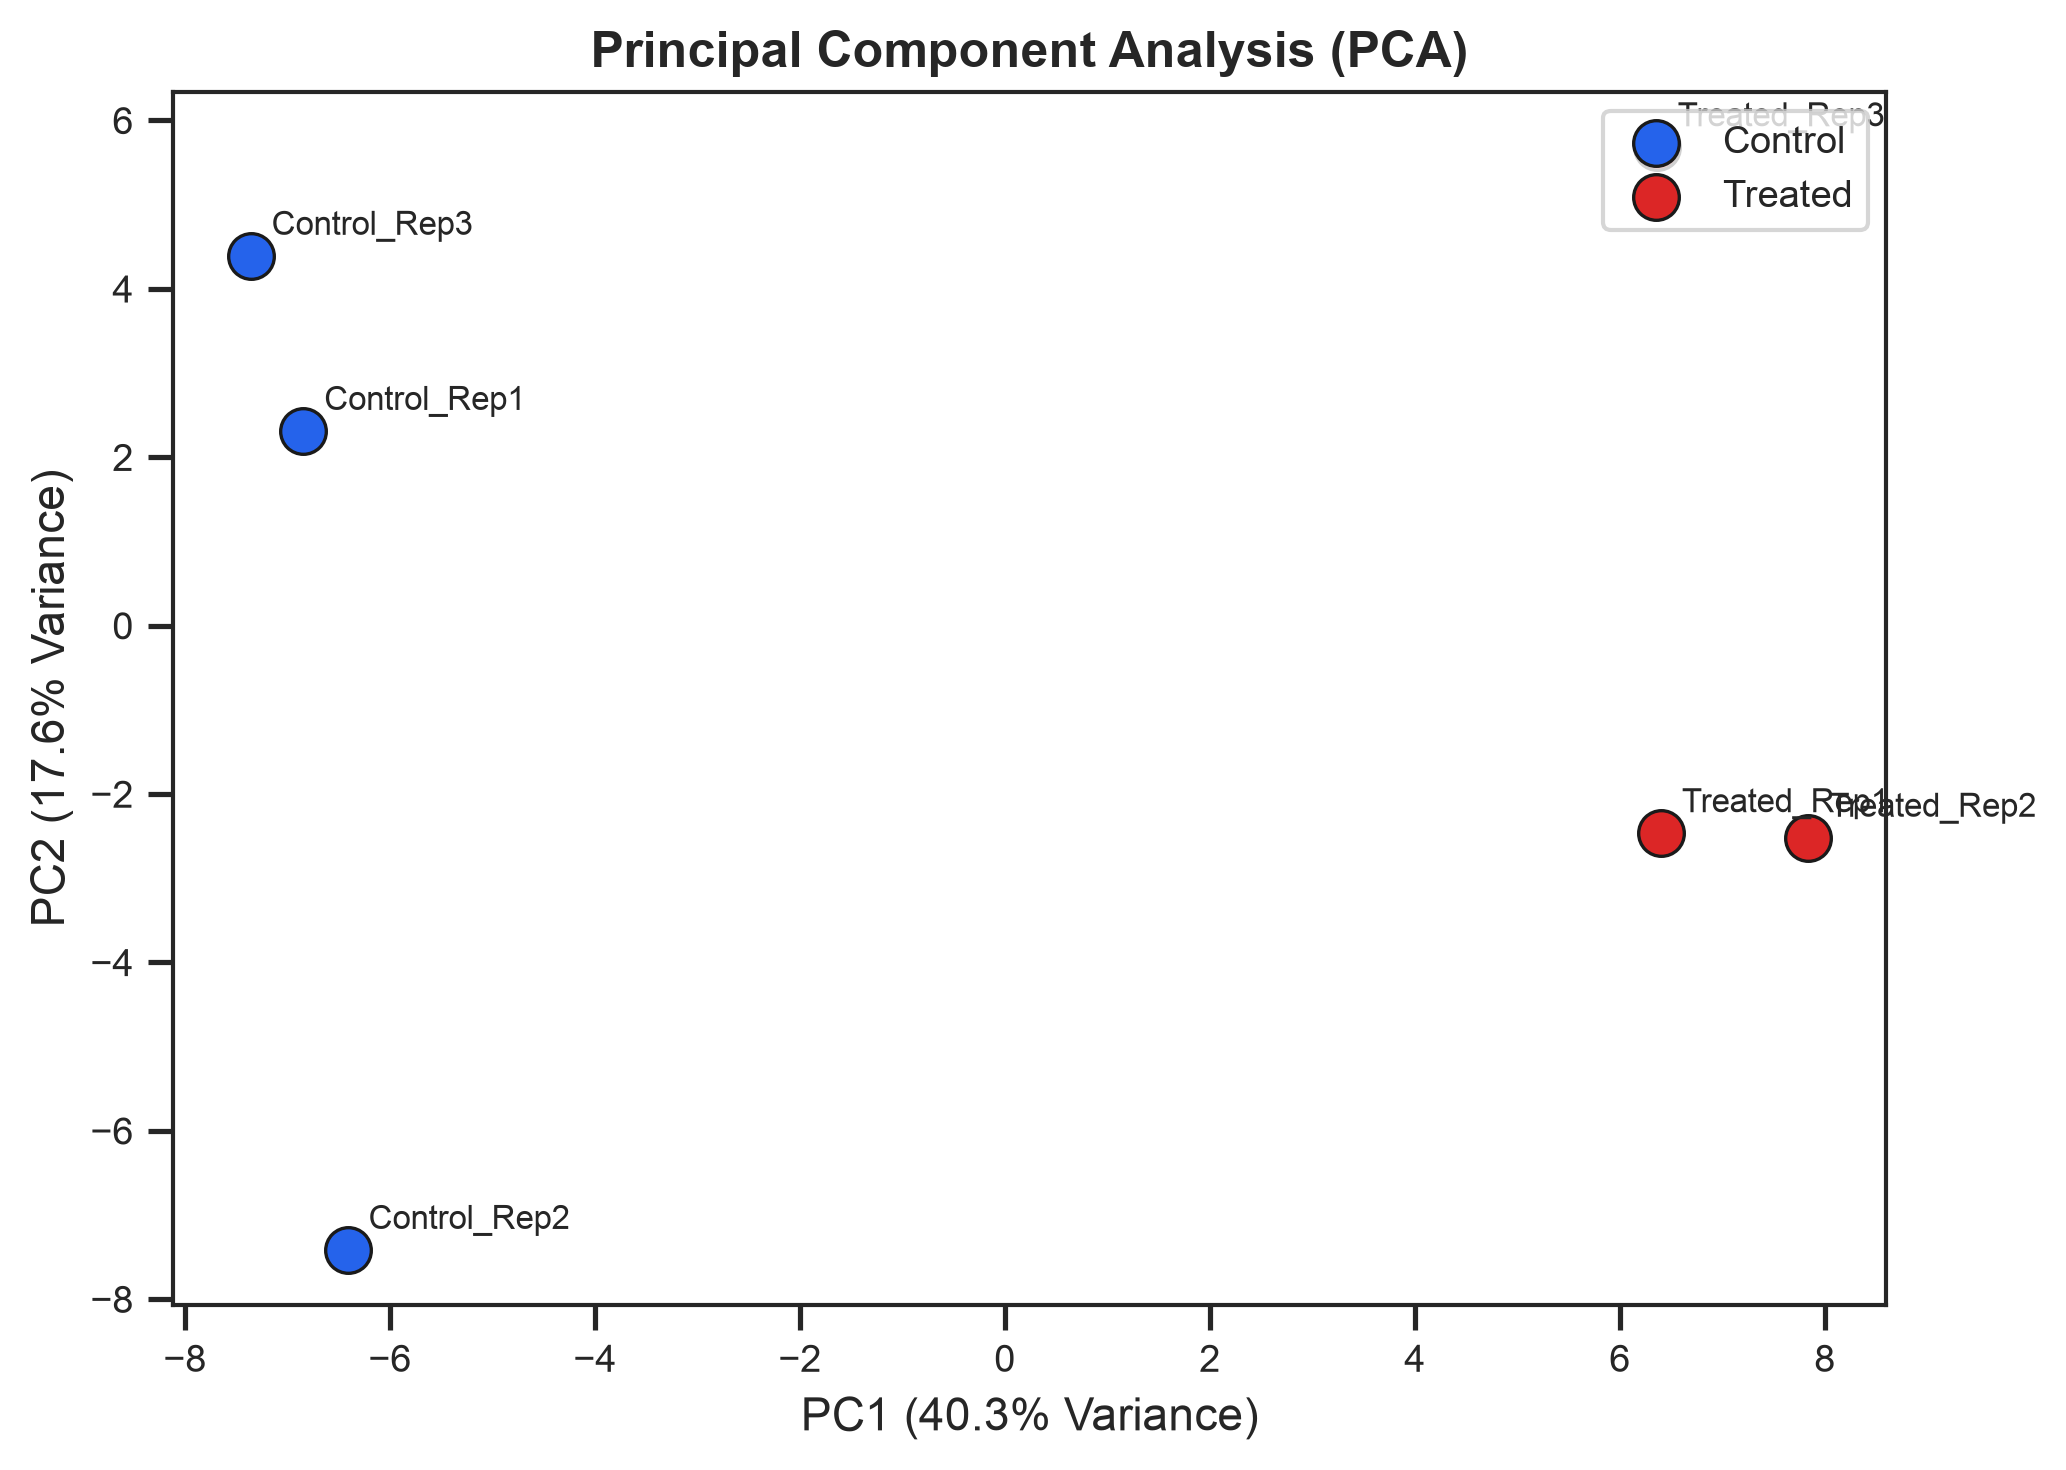

--- Volcano Plot ---


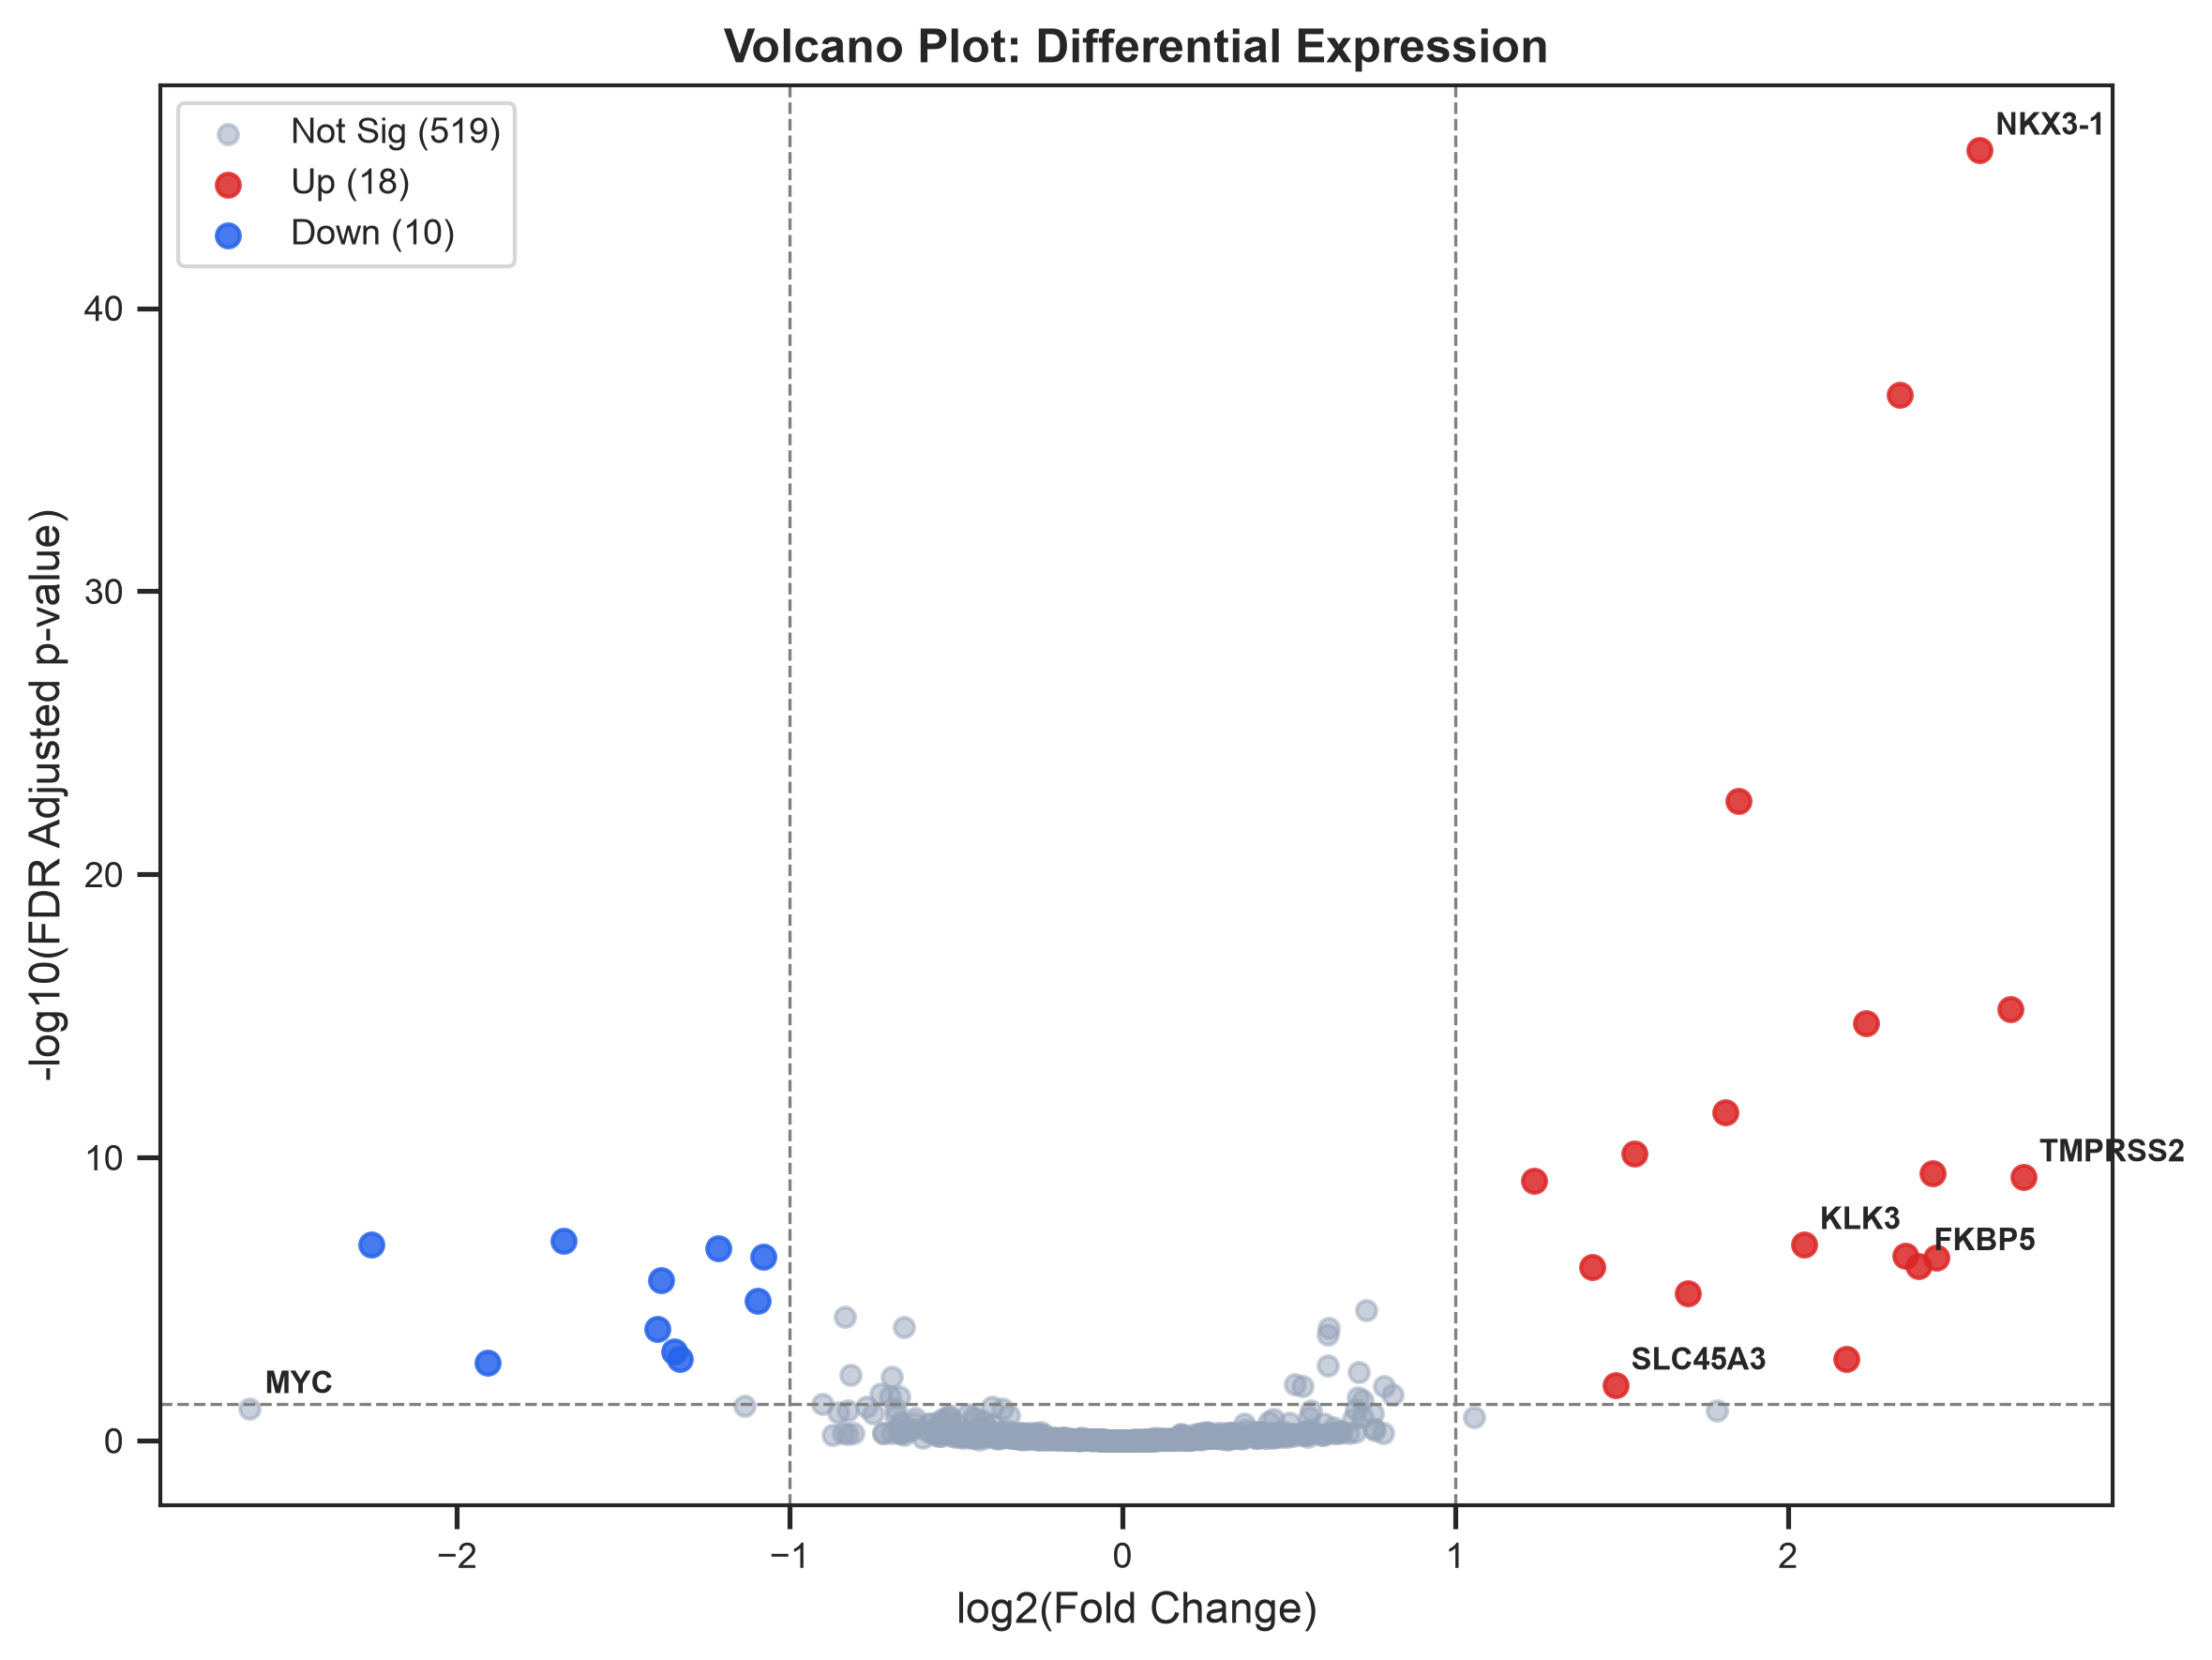

--- Clustered Expression Heatmap ---


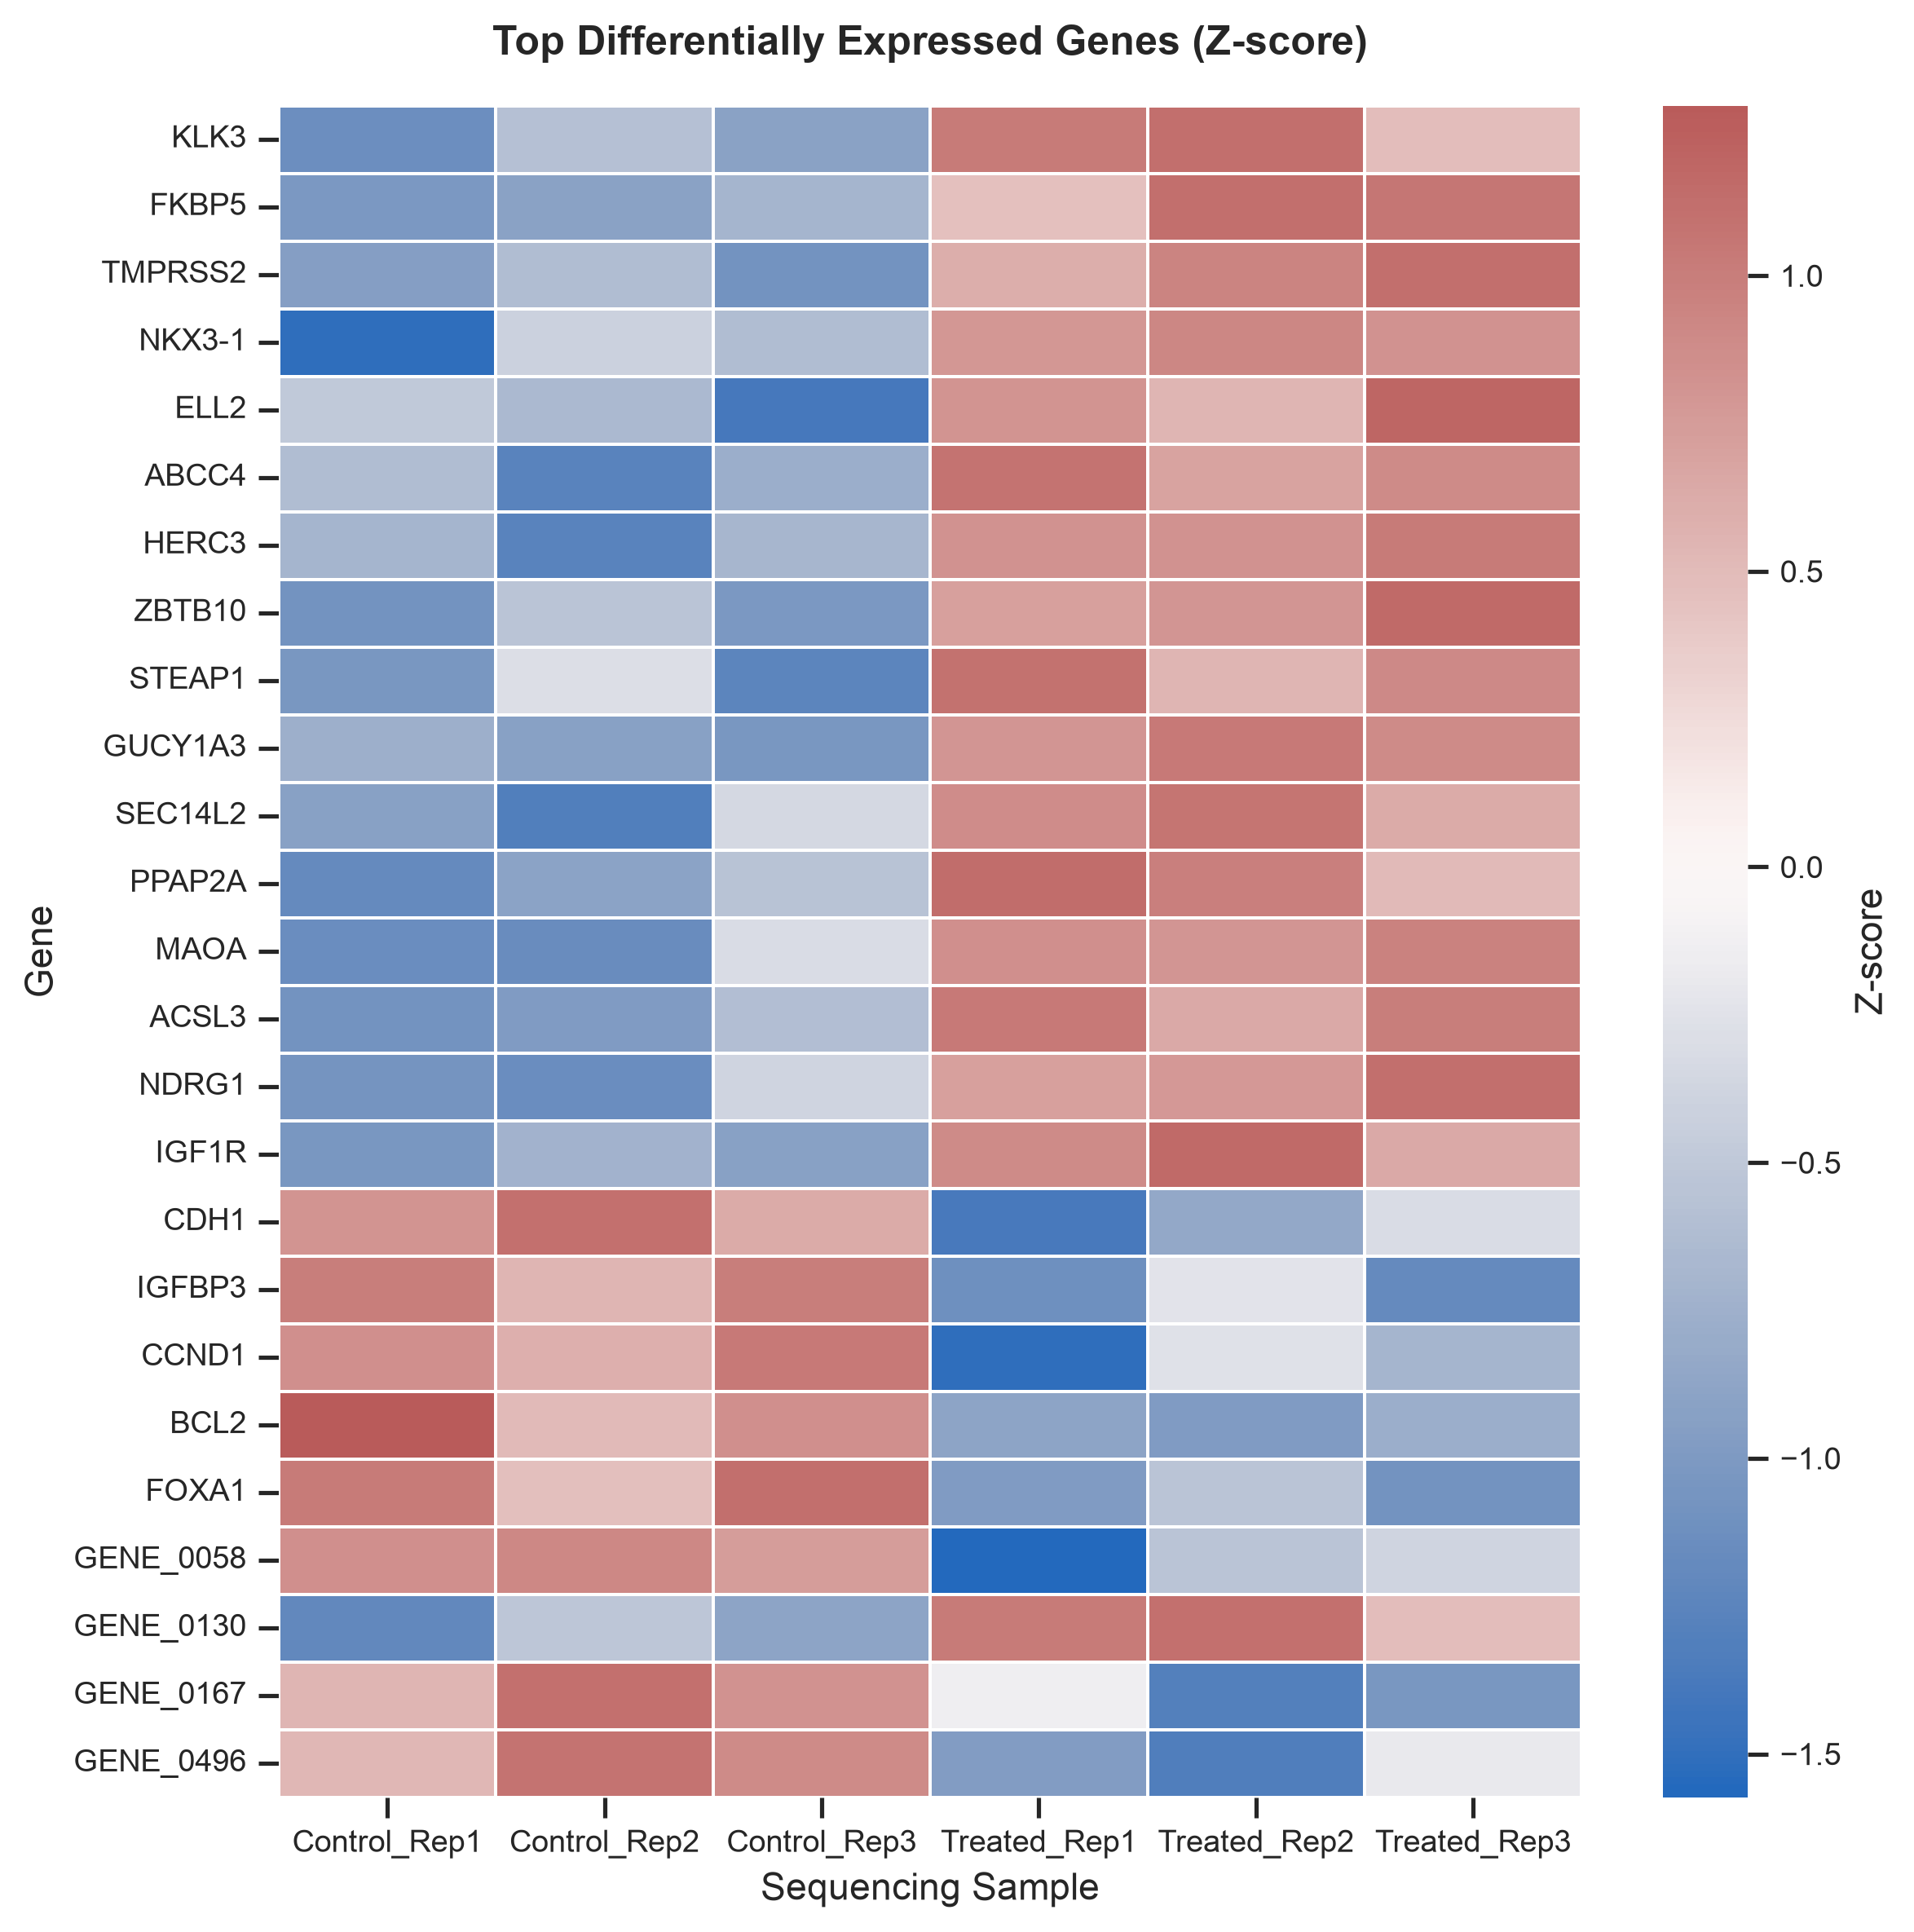

--- Pathway Enrichment Dotplot ---


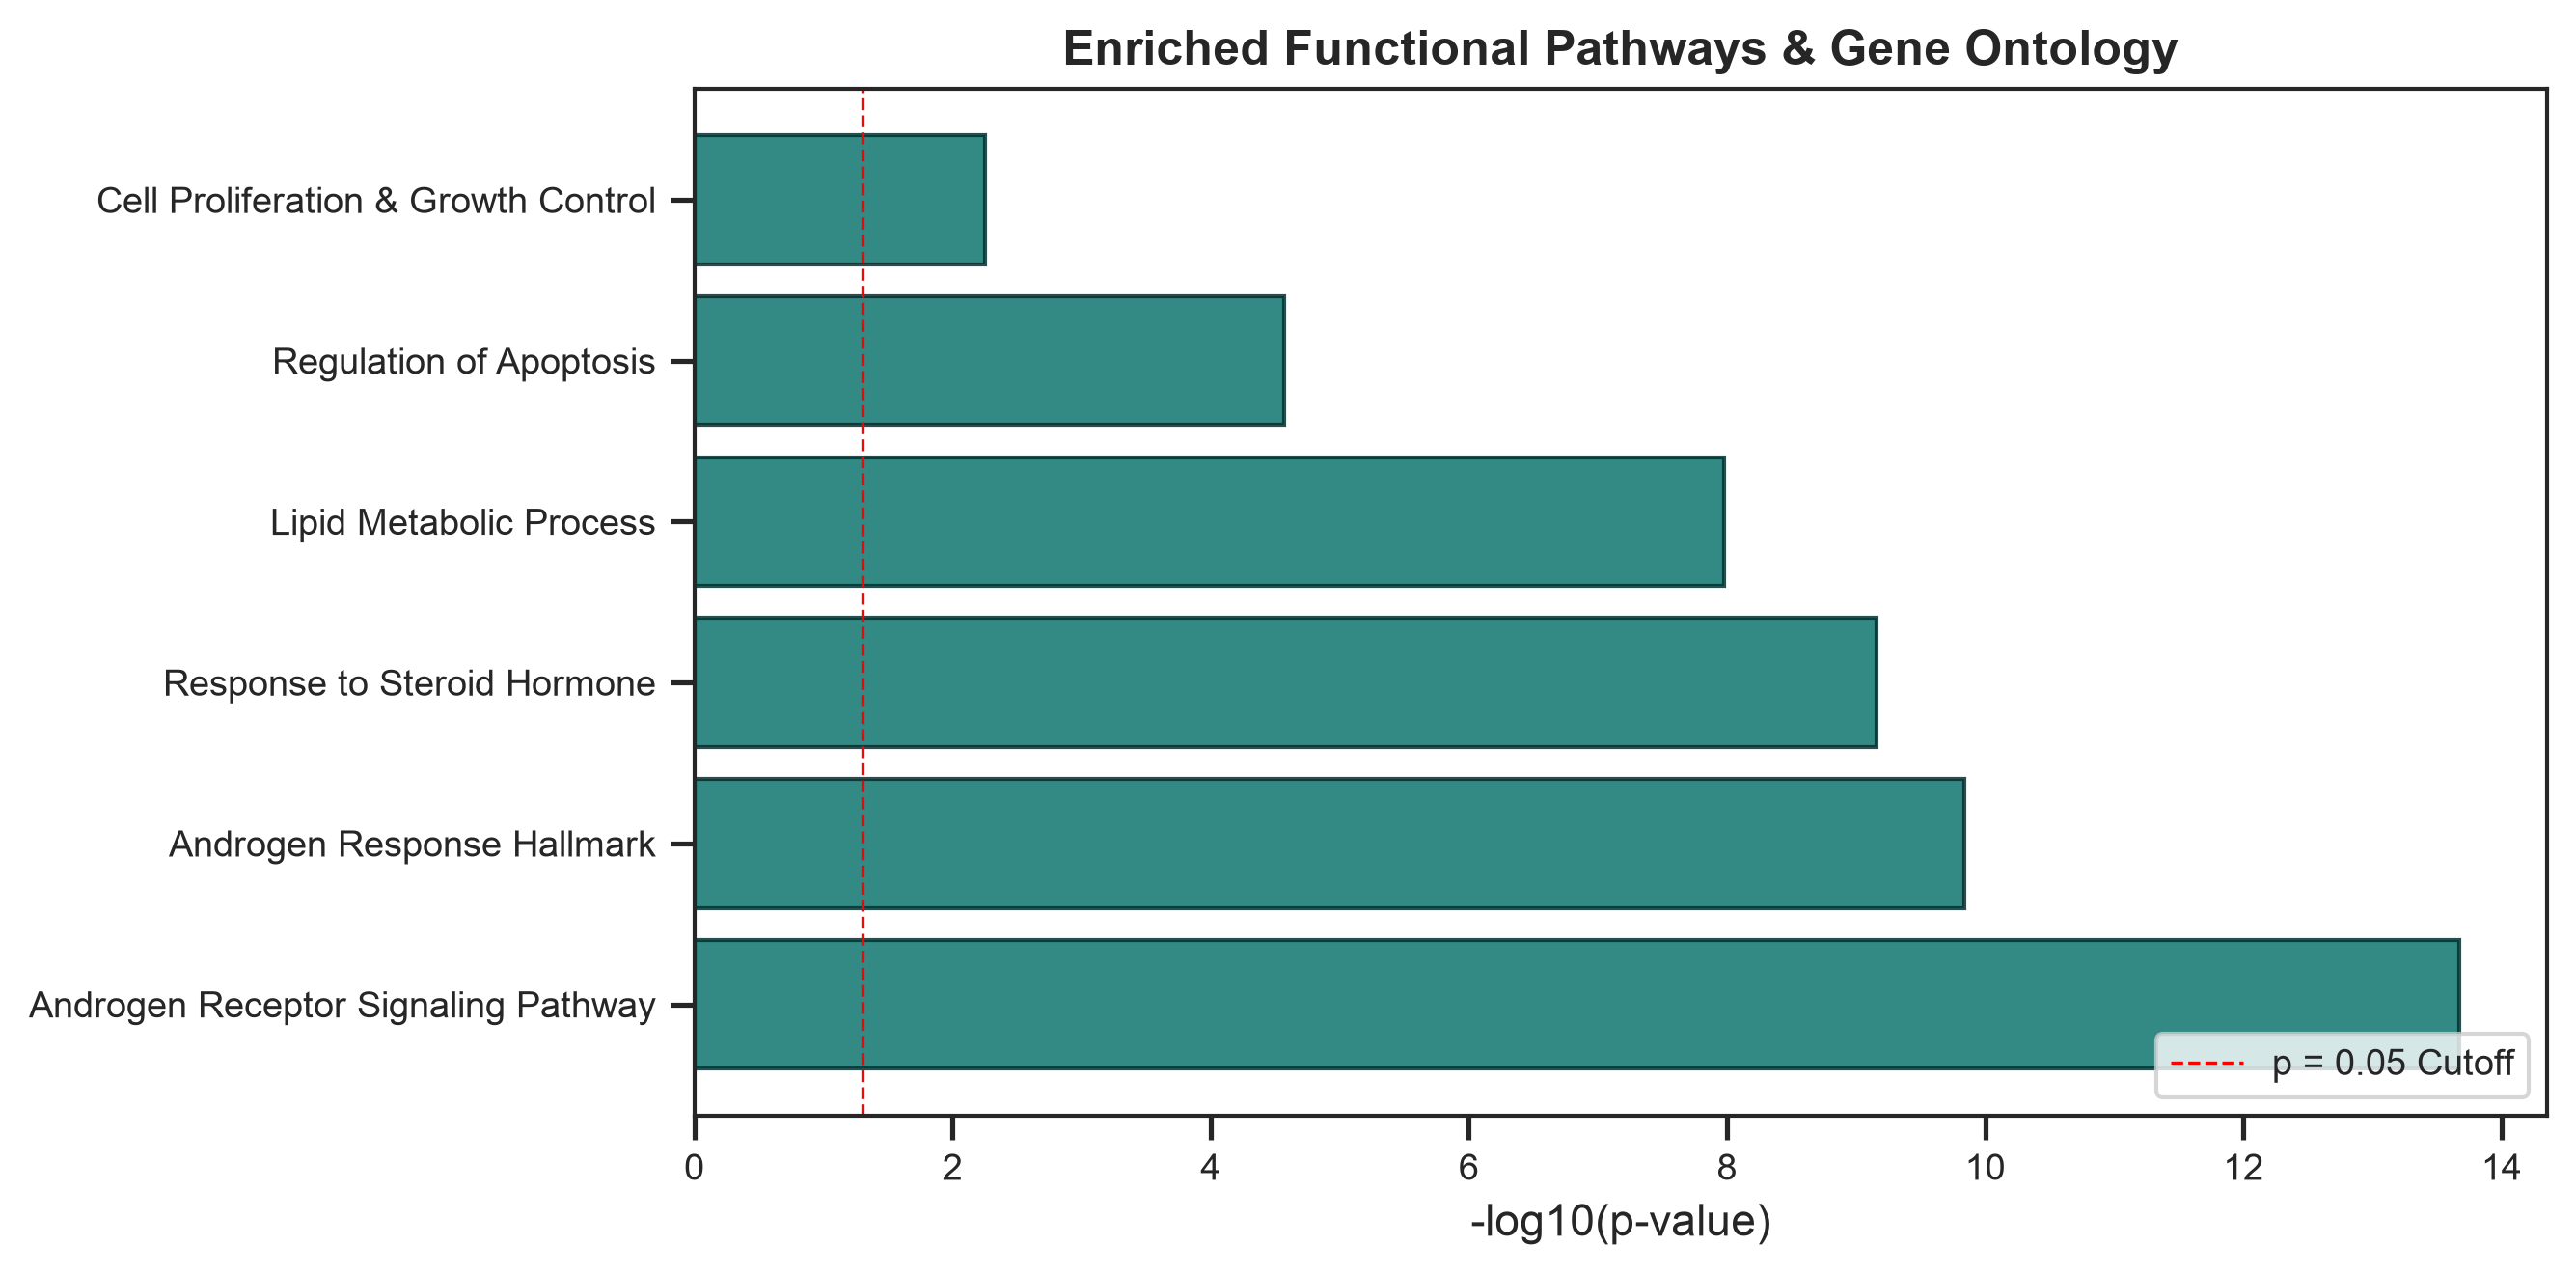

In [6]:
fig_dir = project_dir / "figures"
pca_path = fig_dir / "pca_plot.png"
volcano_path = fig_dir / "volcano_plot.png"
heatmap_path = fig_dir / "expression_heatmap.png"
dotplot_path = fig_dir / "pathway_enrichment_dotplot.png"

plot_pca(log2_counts, all_samples, metadata, pca_path)
plot_volcano(de_results, volcano_path, fdr_cutoff=0.05, log2fc_cutoff=1.0)
plot_expression_heatmap(log2_counts, de_results, all_samples, heatmap_path, n_top=25)
plot_pathway_enrichment(enrichment_df, dotplot_path)

from IPython.display import Image, display

print("--- Principal Component Analysis (PCA) ---")
display(Image(filename=str(pca_path)))
print("--- Volcano Plot ---")
display(Image(filename=str(volcano_path)))
print("--- Clustered Expression Heatmap ---")
display(Image(filename=str(heatmap_path)))
print("--- Pathway Enrichment Dotplot ---")
display(Image(filename=str(dotplot_path)))